In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/amazon.csv')

In [3]:
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [6]:
#create preprocess text function
def preprocess_text(text):
    #tokenize the text
    tokens=word_tokenize(text.lower())
    filtered_tokens=[token for token in tokens if token not in stopwords.words('english')]
    lemmatizer=WordNetLemmatizer()
    lemmatized_tokens=[lemmatizer.lemmatize(token) for token in filtered_tokens]

    processed_text=' '.join(lemmatized_tokens)

    return processed_text

In [12]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [13]:
#apply the function df
df['reviewText']=df['reviewText'].apply(preprocess_text)
df.head(5)

,reviewText,Positive
0,one best apps acording bunch people agree bomb...,1
1,pretty good version game free . lot different ...,1
2,really cool game . bunch level find golden egg...,1
3,"silly game frustrating , lot fun definitely re...",1
4,terrific game pad . hr fun . grandkids love . ...,1


In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [16]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [17]:
#Initialize nltk sentiment analyzer
analyzer=SentimentIntensityAnalyzer()

In [18]:
#create get_sentiment function
def get_sentiment(text):
    scores=analyzer.polarity_scores(text)
    sentiment=1 if scores ['pos']>0 else 0
    return sentiment

In [19]:
#apply get_sentiment function
df['sentiment']=df['reviewText'].apply(get_sentiment)
df.head(5)

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1


In [20]:
from sklearn.metrics import confusion_matrix
result=confusion_matrix(df['Positive'],df['sentiment'])
print (result)

[[ 1131  3636]
 [  576 14657]]


In [21]:
from sklearn.metrics import classification_report
print(classification_report(df['Positive'],df['sentiment']))

              precision    recall  f1-score   support

           0       0.66      0.24      0.35      4767
           1       0.80      0.96      0.87     15233

    accuracy                           0.79     20000
   macro avg       0.73      0.60      0.61     20000
weighted avg       0.77      0.79      0.75     20000



In [22]:
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt

<Axes: xlabel='Predicted', ylabel='Actual'>

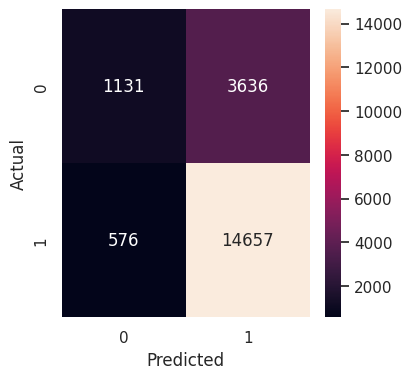

In [23]:
plt.figure(figsize=(4,4))
c_mtrx = pd.crosstab(df['Positive'], df['sentiment'], rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(c_mtrx,annot=True,fmt='.0f')

In [24]:
#[row,column] [Actual,predicted]
TN=result[0,0];FP=result[0,1]
FN=result[1,0];TP=result[1,1]

print ("TN",TN)
print ("FP",FP)
print ("FN",FN)
print ("TP",TP)

TN 1131
FP 3636
FN 576
TP 14657


In [25]:
from sklearn import metrics

y_test=df['Positive']; y_pred=df['sentiment']
# Note: Make sure y_test, y_pred, TN, and FP are defined before running this
print('Metrics computed from a confusion matrix')
print("Accuracy:\t", metrics.accuracy_score(y_test, y_pred) * 100, '%')
print("Sensitivity:\t", metrics.recall_score(y_test, y_pred) * 100, '%')
print("Specificity:\t", TN / (TN + FP) * 100, '%')
print("Precision:\t", metrics.precision_score(y_test, y_pred) * 100, '%')
print("Classification Error:", (1 - metrics.accuracy_score(y_test, y_pred)) * 100, '%')
print("False_Positive_Rate:", (1 - TN / (TN + FP)) * 100, '%')
print('###########################################################')

Metrics computed from a confusion matrix
Accuracy:	 78.94 %
Sensitivity:	 96.21873563972953 %
Specificity:	 23.725613593455 %
Precision:	 80.12354452522823 %
Classification Error: 21.060000000000002 %
False_Positive_Rate: 76.274386406545 %
###########################################################


In [26]:
#get total number of 0 in dataset
count0=df['Positive'][df.Positive==0].count()

#get number of 0 in actual dataset
count1=df['Positive'][df.Positive==1].count()

print("Actual Dataset")
print("0's",count0)
print("1's",count1)

Actual Dataset
0's 4767
1's 15233


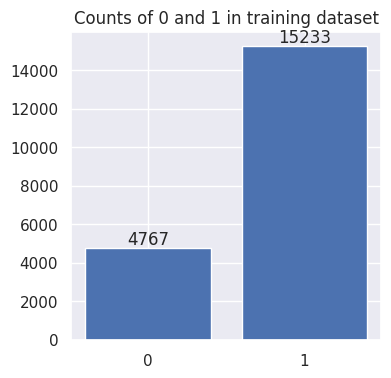

In [27]:
#plotting the barchat
labels=['0','1']
counts=[count0,count1]

plt.figure(figsize=(4,4))
plt.title('Counts of 0 and 1 in training dataset')
plt.bar(labels,counts)

#add annotions to the bar
for i, count in enumerate(counts):
    plt.text(i,count,str(count),ha='center',va='bottom')

plt.show()

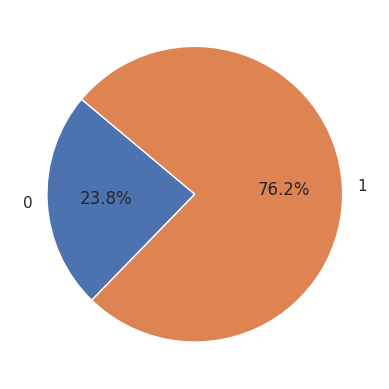

In [28]:
plt.pie(counts,labels=labels,autopct='%1.1f%%',startangle=140)
plt.show()